<a href="https://colab.research.google.com/github/ver1812/Capstone_Project/blob/main/models/BERT_Colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning — BERT-base

**Colab + Drive, second of six transformer notebooks.**

In [1]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import transformers
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "transformers"], check=True)
    import transformers

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

print(f"transformers version: {transformers.__version__}")
print(f"torch version: {torch.__version__}")


transformers version: 5.13.1
torch version: 2.11.0+cu128


### Environment setup (Colab)

In [2]:
import platform

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("=== ENVIRONMENT CHECK ===")
print(f"Platform:       {platform.system()} {platform.machine()}")
print(f"IN_COLAB:       {IN_COLAB}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"GPU memory:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU detected — check Runtime > Change runtime type > GPU.")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Capstone" if IN_COLAB else ".."
DATA_DIR = f"{BASE_DIR}/data_v2"
print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")


=== ENVIRONMENT CHECK ===
Platform:       Linux x86_64
IN_COLAB:       True
CUDA available: True
GPU:            Tesla T4
GPU memory:     15.6 GB
Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/Capstone
DATA_DIR: /content/drive/MyDrive/Capstone/data_v2


### Config

In [3]:
SEED = 42

MODEL_NAME = "bert-base-uncased"
MODEL_SLUG = "bert"

# Data
TEXT_COL = "text"
LABEL_COL = "label"


MAX_LEN = None  # locked below after checking real coverage at the 512 cap

# Training — standard transformer fine-tuning defaults
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
MAX_EPOCHS = 8    # corrected from 4 — the original Kaggle run undertrained
PATIENCE = 3      # corrected from 2, same reason
GRAD_CLIP = 1.0
USE_AMP = True    # mixed precision — genuinely useful for a Transformer's dense attention

# Artifacts — Capstone/saved/{MODEL_SLUG} on Drive
SAVE_DIR = f"{BASE_DIR}/saved/{MODEL_SLUG}"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"
# ------------------------------------------------------------------


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Model: {MODEL_NAME}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"Save dir: {SAVE_DIR}")


Device: cuda
GPU: Tesla T4
Model: bert-base-uncased
AMP enabled: True
Save dir: /content/drive/MyDrive/Capstone/saved/bert


In [4]:
TRAIN_PATH = f"{DATA_DIR}/train_v2.csv"
VAL_PATH   = f"{DATA_DIR}/val_v2.csv"
TEST_PATH  = f"{DATA_DIR}/test_v2.csv"

for _name, _path in [("train_v2.csv", TRAIN_PATH), ("val_v2.csv", VAL_PATH), ("test_v2.csv", TEST_PATH)]:
    if not os.path.exists(_path):
        raise FileNotFoundError(
            f"{_name} not found at {_path} — check DATA_DIR is correct and the "
            "files actually live in that Drive folder."
        )


def load_split(path, text_col, label_col):
    frame = pd.read_csv(path)
    frame[text_col] = frame[text_col].fillna("").astype(str)
    frame[label_col] = frame[label_col].astype(int)
    return frame


train_df = load_split(TRAIN_PATH, TEXT_COL, LABEL_COL)
val_df   = load_split(VAL_PATH,   TEXT_COL, LABEL_COL)
test_df  = load_split(TEST_PATH,  TEXT_COL, LABEL_COL)

for name, frame in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:<6} {len(frame):>7,} rows | {frame[LABEL_COL].mean():.4f} positive")


Train   14,429 rows | 0.4784 positive
Val      3,092 rows | 0.4783 positive
Test     3,093 rows | 0.4785 positive


### Tokenizer & sequence length
The WordPiece tokenizer produces a different length distribution than the BiLSTM's word-level tokenizer  Unlike the BiLSTM, there's no length to *choose* past 512

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Real token counts with NO truncation, to see the true distribution
train_encodings_full = tokenizer(list(train_df[TEXT_COL]), truncation=False)
train_lengths = np.array([len(ids) for ids in train_encodings_full["input_ids"]])

percentiles = [50, 75, 90, 95, 97, 99]
print(f"WordPiece token-length percentiles (train set, {MODEL_NAME} tokenizer):")
for p in percentiles:
    print(f"  p{p:>2}: {int(np.percentile(train_lengths, p)):>6,}")
print(f"  max: {train_lengths.max():>6,}")
print(f" mean: {train_lengths.mean():>6.1f}")

del train_encodings_full


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1716 > 512). Running this sequence through the model will result in indexing errors


WordPiece token-length percentiles (train set, bert-base-uncased tokenizer):
  p50:    119
  p75:    199
  p90:    359
  p95:    883
  p97:  1,012
  p99:  2,446
  max:  4,734
 mean:  217.8


In [6]:
MAX_LEN = 512

coverage_overall = (train_lengths <= MAX_LEN).mean()
coverage_benign = (train_lengths[train_df[LABEL_COL].values == 0] <= MAX_LEN).mean()
coverage_malicious = (train_lengths[train_df[LABEL_COL].values == 1] <= MAX_LEN).mean()

print(f"MAX_LEN = {MAX_LEN}")
print(f"Overall coverage:   {coverage_overall:.2%}")
print(f"Benign coverage:    {coverage_benign:.2%}")
print(f"Malicious coverage: {coverage_malicious:.2%}")


MAX_LEN = 512
Overall coverage:   93.05%
Benign coverage:    93.34%
Malicious coverage: 92.73%


### Dataset & DataLoader (dynamic padding)


In [7]:
class TransformerPromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=max_len, padding=False)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_ds = TransformerPromptDataset(train_df[TEXT_COL], train_df[LABEL_COL], tokenizer, MAX_LEN)
val_ds   = TransformerPromptDataset(val_df[TEXT_COL],   val_df[LABEL_COL],   tokenizer, MAX_LEN)
test_ds  = TransformerPromptDataset(test_df[TEXT_COL],  test_df[LABEL_COL],  tokenizer, MAX_LEN)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator, collate_fn=data_collator)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches — train: 451, val: 97, test: 97


### Model

In [8]:

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model on device: {next(model.parameters()).device}")


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     109,483,009
Trainable parameters: 109,483,009
Model on device: cuda:0


### Loss, optimizer, scheduler

In [9]:
num_neg = int((train_df[LABEL_COL] == 0).sum())
num_pos = int((train_df[LABEL_COL] == 1).sum())
pos_weight_value = num_neg / num_pos

print(f"Negatives: {num_neg:,} | Positives: {num_pos:,}")
print(f"pos_weight = {pos_weight_value:.4f}")

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float, device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(f"Total optimizer steps: {total_steps:,} (warmup: {warmup_steps:,})")


Negatives: 7,526 | Positives: 6,903
pos_weight = 1.0903
Total optimizer steps: 3,608 (warmup: 360)


/tmp/ipykernel_1779/3435023473.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


### Train and evaluate functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, grad_clip, epoch_num, total_epochs, print_every=40):
    model.train()
    running_loss = 0.0
    n_batches = len(loader)
    batch_start = time.time()

    for batch_idx, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * input_ids.size(0)

        if batch_idx == 1 or batch_idx % print_every == 0 or batch_idx == n_batches:
            elapsed = time.time() - batch_start
            avg_batch_time = elapsed / batch_idx
            eta_sec = avg_batch_time * (n_batches - batch_idx)
            print(
                f"  [Epoch {epoch_num}/{total_epochs}] batch {batch_idx}/{n_batches} "
                f"| loss {loss.item():.4f} | {avg_batch_time:.2f}s/batch | ETA {eta_sec:.0f}s",
                flush=True,
            )

    return running_loss / len(loader.dataset)


def predict(model, loader, criterion, device, desc="eval"):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits.squeeze(-1)
                loss = criterion(logits, labels)

            running_loss += loss.item() * input_ids.size(0)

            probs = torch.sigmoid(logits.float())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    return avg_loss, np.concatenate(all_labels), np.concatenate(all_probs)


### Helper functions

In [11]:
def evaluate_predictions(y_true, y_prob, threshold=0.5, split_name=""):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }


def print_metrics(metrics):
    print(f"--- {metrics['split']} (threshold={metrics['threshold']:.2f}) ---")
    for key in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
        print(f"  {key:<10}: {metrics[key]:.4f}")


Quick timing check before committing to the full run — same pattern used throughout this project. Given the uncertainty flagged earlier about per-model training cost, don't skip this one.

In [13]:
model.train()
single_batch = next(iter(train_loader))
input_ids = single_batch["input_ids"].to(DEVICE)
attention_mask = single_batch["attention_mask"].to(DEVICE)
labels = single_batch["labels"].to(DEVICE)

start = time.time()
optimizer.zero_grad()
with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits.squeeze(-1)
    loss = criterion(logits, labels)
scaler.scale(loss).backward()
scaler.unscale_(optimizer)
nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
scaler.step(optimizer)
scaler.update()
scheduler.step()
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
batch_time = time.time() - start

print(f"Single batch time ({DEVICE}, AMP={AMP_ENABLED}, MAX_LEN={MAX_LEN}, batch={BATCH_SIZE}): {batch_time:.3f}s")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Rough epoch estimate: {batch_time * len(train_loader) / 60:.1f} min")
print(f"Rough {MAX_EPOCHS}-epoch estimate: {batch_time * len(train_loader) * MAX_EPOCHS / 60:.1f} min")


/tmp/ipykernel_1779/3609877095.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Single batch time (cuda, AMP=True, MAX_LEN=512, batch=32): 0.784s
Batches per epoch: 451
Rough epoch estimate: 5.9 min
Rough 8-epoch estimate: 47.1 min


### Training loop

In [15]:
best_val_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []

checkpoint_dir = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_best")

print(f"Starting training — up to {MAX_EPOCHS} epochs, early stopping patience={PATIENCE}\n")

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler,
        DEVICE, GRAD_CLIP, epoch, MAX_EPOCHS
    )
    val_loss, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]")
    val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")

    elapsed = time.time() - start

    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "val_f1": val_metrics["f1"], "val_recall": val_metrics["recall"],
        "val_precision": val_metrics["precision"], "seconds": elapsed,
    })

    print(
        f"Epoch {epoch:>2}/{MAX_EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
        f"| val_F1 {val_metrics['f1']:.4f} | val_recall {val_metrics['recall']:.4f} | {elapsed:.1f}s"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(checkpoint_dir)
        tokenizer.save_pretrained(checkpoint_dir)
        print("         -> new best val F1, checkpoint saved")
    else:
        epochs_without_improvement += 1
        print(f"         -> no improvement ({epochs_without_improvement}/{PATIENCE})")
        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}, best val F1: {best_val_f1:.4f}.")
            break

history_df = pd.DataFrame(history)
print(f"\nTraining complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")


Starting training — up to 8 epochs, early stopping patience=3



/tmp/ipykernel_1779/1074905201.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 1/8] batch 1/451 | loss 0.7168 | 0.78s/batch | ETA 351s
  [Epoch 1/8] batch 40/451 | loss 0.7219 | 0.68s/batch | ETA 280s
  [Epoch 1/8] batch 80/451 | loss 0.6476 | 0.70s/batch | ETA 260s
  [Epoch 1/8] batch 120/451 | loss 0.6733 | 0.74s/batch | ETA 244s
  [Epoch 1/8] batch 160/451 | loss 0.5227 | 0.75s/batch | ETA 219s
  [Epoch 1/8] batch 200/451 | loss 0.2814 | 0.76s/batch | ETA 191s
  [Epoch 1/8] batch 240/451 | loss 0.3239 | 0.76s/batch | ETA 161s
  [Epoch 1/8] batch 280/451 | loss 0.3581 | 0.77s/batch | ETA 131s
  [Epoch 1/8] batch 320/451 | loss 0.3145 | 0.77s/batch | ETA 101s
  [Epoch 1/8] batch 360/451 | loss 0.3486 | 0.77s/batch | ETA 70s
  [Epoch 1/8] batch 400/451 | loss 0.1252 | 0.77s/batch | ETA 40s
  [Epoch 1/8] batch 440/451 | loss 0.2164 | 0.78s/batch | ETA 9s
  [Epoch 1/8] batch 451/451 | loss 0.2076 | 0.78s/batch | ETA 0s


/tmp/ipykernel_1779/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  1/8 | train_loss 0.4341 | val_loss 0.2387 | val_F1 0.9047 | val_recall 0.8668 | 374.5s


...

Epoch  6/8 | train_loss 0.0522 | val_loss 0.3028 | val_F1 0.9344 | val_recall 0.9006 | 377.6s
         -> no improvement (2/3)


/tmp/ipykernel_1779/1074905201.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


  [Epoch 7/8] batch 1/451 | loss 0.1934 | 0.79s/batch | ETA 355s
  [Epoch 7/8] batch 40/451 | loss 0.0018 | 0.78s/batch | ETA 320s
  [Epoch 7/8] batch 80/451 | loss 0.0076 | 0.77s/batch | ETA 287s
  [Epoch 7/8] batch 120/451 | loss 0.0087 | 0.77s/batch | ETA 255s
  [Epoch 7/8] batch 160/451 | loss 0.0800 | 0.77s/batch | ETA 225s
  [Epoch 7/8] batch 200/451 | loss 0.0005 | 0.78s/batch | ETA 195s
  [Epoch 7/8] batch 240/451 | loss 0.0893 | 0.78s/batch | ETA 165s
  [Epoch 7/8] batch 280/451 | loss 0.0009 | 0.78s/batch | ETA 134s
  [Epoch 7/8] batch 320/451 | loss 0.0003 | 0.78s/batch | ETA 102s
  [Epoch 7/8] batch 360/451 | loss 0.2081 | 0.78s/batch | ETA 71s
  [Epoch 7/8] batch 400/451 | loss 0.0010 | 0.78s/batch | ETA 40s
  [Epoch 7/8] batch 440/451 | loss 0.0035 | 0.78s/batch | ETA 9s
  [Epoch 7/8] batch 451/451 | loss 0.1282 | 0.78s/batch | ETA 0s


/tmp/ipykernel_1779/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch  7/8 | train_loss 0.0434 | val_loss 0.3125 | val_F1 0.9357 | val_recall 0.9047 | 376.0s
         -> no improvement (3/3)

Early stopping at epoch 7. Best epoch: 4, best val F1: 0.9399.

Training complete. Best val F1 = 0.9399 at epoch 4


### Load checkpoint and evaluate

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir).to(DEVICE)

_, val_true, val_prob = predict(model, val_loader, criterion, DEVICE, desc="final val")
val_metrics = evaluate_predictions(val_true, val_prob, 0.5, "val")
print_metrics(val_metrics)

_, test_true, test_prob = predict(model, test_loader, criterion, DEVICE, desc="final test")
test_metrics = evaluate_predictions(test_true, test_prob, 0.5, "test")
print_metrics(test_metrics)

print("\nConfusion matrix (test, threshold=0.5):")
test_pred = (test_prob >= 0.5).astype(int)
cm = confusion_matrix(test_true, test_pred)
print(pd.DataFrame(cm, index=["actual_benign", "actual_malicious"], columns=["pred_benign", "pred_malicious"]))

print("\n" + classification_report(test_true, test_pred, digits=4))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_1779/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- val (threshold=0.50) ---
  accuracy  : 0.9440
  precision : 0.9664
  recall    : 0.9148
  f1        : 0.9399
  roc_auc   : 0.9821
  pr_auc    : 0.9842


/tmp/ipykernel_1779/1074905201.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


--- test (threshold=0.50) ---
  accuracy  : 0.9334
  precision : 0.9636
  recall    : 0.8946
  f1        : 0.9278
  roc_auc   : 0.9755
  pr_auc    : 0.9787

Confusion matrix (test, threshold=0.5):
                  pred_benign  pred_malicious
actual_benign            1563              50
actual_malicious          156            1324

              precision    recall  f1-score   support

         0.0     0.9092    0.9690    0.9382      1613
         1.0     0.9636    0.8946    0.9278      1480

    accuracy                         0.9334      3093
   macro avg     0.9364    0.9318    0.9330      3093
weighted avg     0.9353    0.9334    0.9332      3093



ROC curve

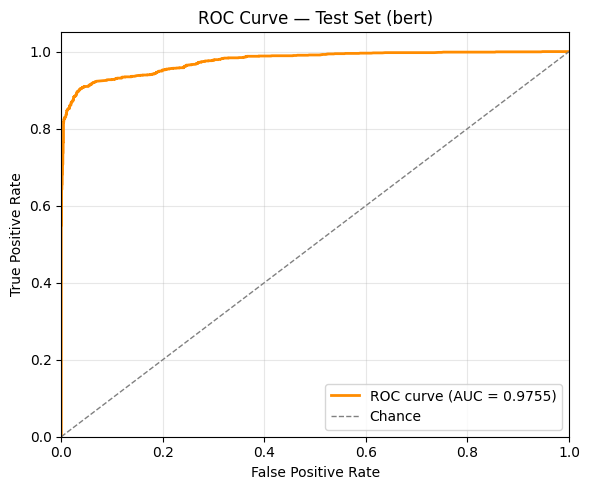

Saved: /content/drive/MyDrive/Capstone/saved/bert/roc_curve_bert.png


In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(test_true, test_prob)
roc_auc_value = test_metrics["roc_auc"]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — Test Set ({MODEL_SLUG})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(SAVE_DIR, f"roc_curve_{MODEL_SLUG}.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {roc_path}")


Confusion matrix (visual)

Confusion matrix (visual) — validation set

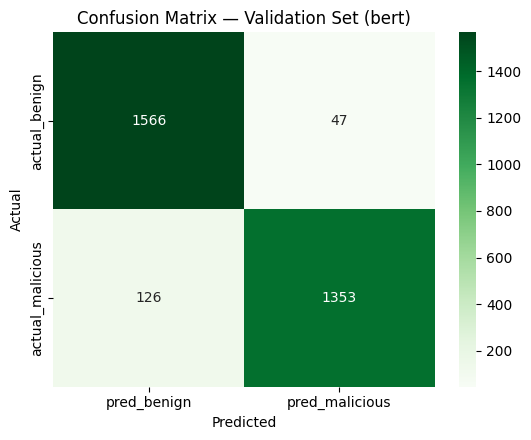

Saved: /content/drive/MyDrive/Capstone/saved/bert/confusion_matrix_val_bert.png


In [19]:
val_pred = (val_prob >= 0.5).astype(int)
val_cm = confusion_matrix(val_true, val_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    val_cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Validation Set ({MODEL_SLUG})")
plt.tight_layout()

val_cm_path = os.path.join(SAVE_DIR, f"confusion_matrix_val_{MODEL_SLUG}.png")
plt.savefig(val_cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {val_cm_path}")


### Save metrics/history

In [20]:
config = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "model_slug": MODEL_SLUG,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "warmup_ratio": WARMUP_RATIO,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "grad_clip": GRAD_CLIP,
    "amp_enabled": AMP_ENABLED,
    "pos_weight": pos_weight_value,
    "best_epoch": best_epoch,
    "best_val_f1": best_val_f1,
    "total_params": total_params,
    "trainable_params": trainable_params,
    "device": str(DEVICE),
}
with open(os.path.join(SAVE_DIR, f"config_{MODEL_SLUG}.json"), "w") as f:
    json.dump(config, f, indent=2)

results = pd.DataFrame([val_metrics, test_metrics])
results.to_csv(os.path.join(SAVE_DIR, f"metrics_{MODEL_SLUG}.csv"), index=False)
history_df.to_csv(os.path.join(SAVE_DIR, f"history_{MODEL_SLUG}.csv"), index=False)

print("Saved:")
for root, dirs, files in os.walk(SAVE_DIR):
    for f in files:
        print(f"  {os.path.join(root, f)}")

results


Saved:
  /content/drive/MyDrive/Capstone/saved/bert/loss_curve_bert.png
  /content/drive/MyDrive/Capstone/saved/bert/roc_curve_bert.png
  /content/drive/MyDrive/Capstone/saved/bert/confusion_matrix_val_bert.png
  /content/drive/MyDrive/Capstone/saved/bert/config_bert.json
  /content/drive/MyDrive/Capstone/saved/bert/metrics_bert.csv
  /content/drive/MyDrive/Capstone/saved/bert/history_bert.csv
  /content/drive/MyDrive/Capstone/saved/bert/bert_best/config.json
  /content/drive/MyDrive/Capstone/saved/bert/bert_best/model.safetensors
  /content/drive/MyDrive/Capstone/saved/bert/bert_best/tokenizer_config.json
  /content/drive/MyDrive/Capstone/saved/bert/bert_best/tokenizer.json


,split,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,val,0.5,0.944049,0.966429,0.914807,0.939910,0.982098,0.984204
1,test,0.5,0.933398,0.963610,0.894595,0.927821,0.975544,0.978675


Results summary (JSON, matches the traditional ML / BiLSTM v2 format — includes raw confusion-matrix counts)

In [21]:
tn, fp, fn, tp = cm.ravel()
val_tn, val_fp, val_fn, val_tp = val_cm.ravel()

results_summary = {
    MODEL_SLUG: {
        "config": MODEL_SLUG,
        "validation": val_metrics,
        "test": test_metrics,
        "validation_confusion_matrix": {
            "tn": int(val_tn), "fp": int(val_fp), "fn": int(val_fn), "tp": int(val_tp),
        },
        "test_confusion_matrix": {
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        },
    }
}

results_json_path = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_results.json")
with open(results_json_path, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Saved results summary to {results_json_path}")
print(f"Test:       TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Validation: TN={val_tn}, FP={val_fp}, FN={val_fn}, TP={val_tp}")


Saved results summary to /content/drive/MyDrive/Capstone/saved/bert/bert_results.json
Test:       TN=1563, FP=50, FN=156, TP=1324
Validation: TN=1566, FP=47, FN=126, TP=1353


 threshold  accuracy  precision  recall     f1  FN  FP
      0.05    0.9033     0.8554  0.9601 0.9047  59 240
      0.10    0.9253     0.9000  0.9493 0.9240  75 156
      0.15    0.9424     0.9446  0.9344 0.9395  97  81
      0.20    0.9428     0.9540  0.9249 0.9392 111  66
      0.25    0.9437     0.9579  0.9229 0.9401 114  60
      0.30    0.9431     0.9604  0.9189 0.9392 120  56
      0.35    0.9428     0.9610  0.9175 0.9388 122  55
      0.40    0.9431     0.9624  0.9168 0.9391 123  53
      0.45    0.9444     0.9651  0.9168 0.9404 123  49
      0.50    0.9440     0.9664  0.9148 0.9399 126  47
      0.55    0.9453     0.9692  0.9148 0.9412 126  43
      0.60    0.9444     0.9691  0.9128 0.9401 129  43
      0.65    0.9431     0.9690  0.9101 0.9386 133  43
      0.70    0.9428     0.9697  0.9087 0.9382 135  42
      0.75    0.9421     0.9697  0.9074 0.9375 137  42
      0.80    0.9415     0.9710  0.9047 0.9366 141  40
      0.85    0.9402     0.9709  0.9020 0.9352 145  40
      0.90

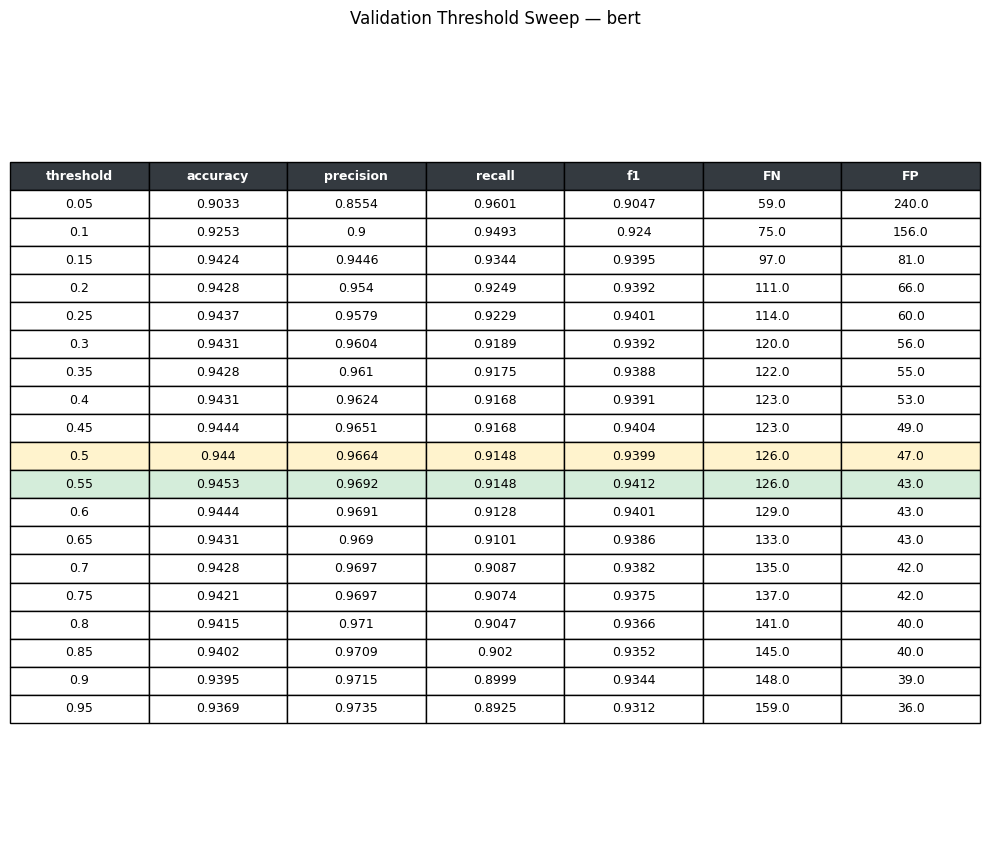

Saved: /content/drive/MyDrive/Capstone/saved/bert/threshold_sweep_table_bert.png


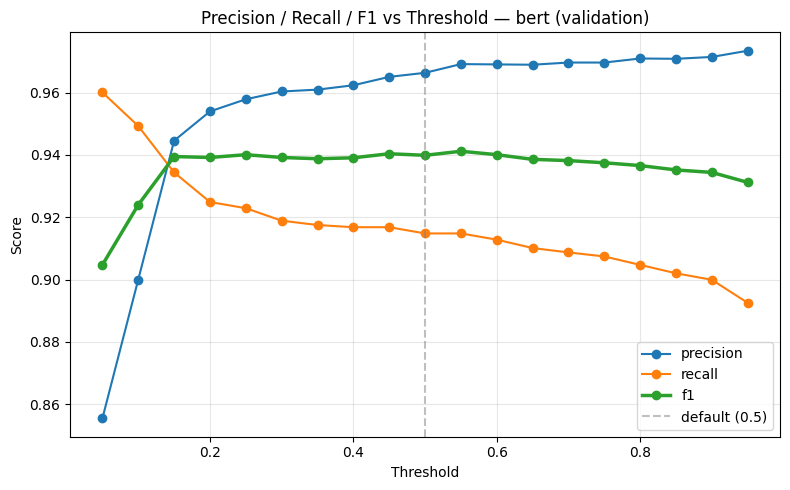

Saved: /content/drive/MyDrive/Capstone/saved/bert/threshold_tradeoff_bert.png


In [23]:
thresholds_to_check = np.arange(0.05, 0.96, 0.05)

sweep_rows = []
for t in thresholds_to_check:
    m = evaluate_predictions(val_true, val_prob, threshold=t, split_name="val")
    pred = (val_prob >= t).astype(int)
    fn = int(((val_true == 1) & (pred == 0)).sum())
    fp = int(((val_true == 0) & (pred == 1)).sum())
    sweep_rows.append({
        "threshold": round(float(t), 2),
        "accuracy": round(m["accuracy"], 4),
        "precision": round(m["precision"], 4),
        "recall": round(m["recall"], 4),
        "f1": round(m["f1"], 4),
        "FN": fn,
        "FP": fp,
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

# --- Graphic table ---
fig, ax = plt.subplots(figsize=(10, 0.4 * len(sweep_df) + 1))
ax.axis("off")

table = ax.table(
    cellText=sweep_df.values,
    colLabels=sweep_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Highlight default threshold row (yellow) and best-F1 row (green)
default_idx = sweep_df.index[sweep_df["threshold"] == 0.50].tolist()
if default_idx:
    for col in range(len(sweep_df.columns)):
        table[(default_idx[0] + 1, col)].set_facecolor("#FFF3CD")

best_f1_idx = int(sweep_df["f1"].idxmax())
for col in range(len(sweep_df.columns)):
    table[(best_f1_idx + 1, col)].set_facecolor("#D4EDDA")

for col in range(len(sweep_df.columns)):
    table[(0, col)].set_facecolor("#343A40")
    table[(0, col)].set_text_props(color="white", weight="bold")

plt.title(f"Validation Threshold Sweep — {MODEL_SLUG}", fontsize=12, pad=15)
plt.tight_layout()

sweep_table_path = os.path.join(SAVE_DIR, f"threshold_sweep_table_{MODEL_SLUG}.png")
plt.savefig(sweep_table_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {sweep_table_path}")

# --- Companion tradeoff curve — cheap to add, shows the shape a table can't ---
plt.figure(figsize=(8, 5))
plt.plot(sweep_df["threshold"], sweep_df["precision"], marker="o", label="precision")
plt.plot(sweep_df["threshold"], sweep_df["recall"], marker="o", label="recall")
plt.plot(sweep_df["threshold"], sweep_df["f1"], marker="o", label="f1", linewidth=2.5)
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs Threshold — {MODEL_SLUG} (validation)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

tradeoff_path = os.path.join(SAVE_DIR, f"threshold_tradeoff_{MODEL_SLUG}.png")
plt.savefig(tradeoff_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {tradeoff_path}")

--- val @ 0.15 (threshold=0.15) ---
  accuracy  : 0.9424
  precision : 0.9446
  recall    : 0.9344
  f1        : 0.9395
  roc_auc   : 0.9821
  pr_auc    : 0.9842
--- test @ 0.15 (threshold=0.15) ---
  accuracy  : 0.9295
  precision : 0.9382
  recall    : 0.9128
  f1        : 0.9253
  roc_auc   : 0.9755
  pr_auc    : 0.9787

Classification report (test @ 0.15):
              precision    recall  f1-score   support

         0.0     0.9220    0.9448    0.9333      1613
         1.0     0.9382    0.9128    0.9253      1480

    accuracy                         0.9295      3093
   macro avg     0.9301    0.9288    0.9293      3093
weighted avg     0.9297    0.9295    0.9295      3093



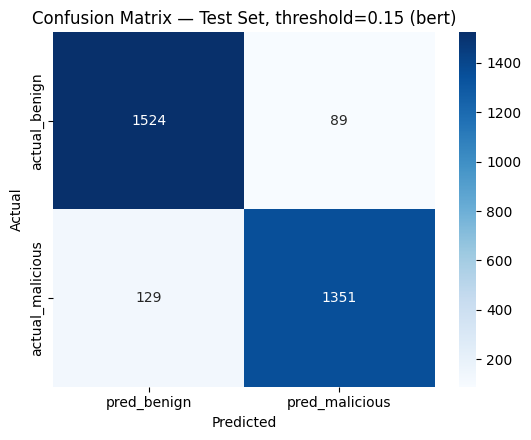

Saved: /content/drive/MyDrive/Capstone/saved/bert/confusion_matrix_tuned_bert.png


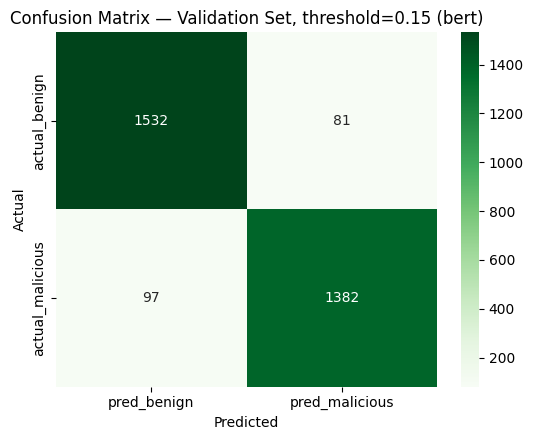

Saved: /content/drive/MyDrive/Capstone/saved/bert/confusion_matrix_val_tuned_bert.png

Saved tuned-threshold results to /content/drive/MyDrive/Capstone/saved/bert/bert_results_threshold0.15.json
Test @ 0.15:       TN=1524, FP=89, FN=129, TP=1351
Validation @ 0.15: TN=1532, FP=81, FN=97, TP=1382


In [24]:
CHOSEN_THRESHOLD = 0.15

# --- Full metrics at the tuned threshold, both splits ---
val_metrics_tuned = evaluate_predictions(val_true, val_prob, threshold=CHOSEN_THRESHOLD, split_name=f"val @ {CHOSEN_THRESHOLD}")
test_metrics_tuned = evaluate_predictions(test_true, test_prob, threshold=CHOSEN_THRESHOLD, split_name=f"test @ {CHOSEN_THRESHOLD}")

print_metrics(val_metrics_tuned)
print_metrics(test_metrics_tuned)

test_pred_tuned = (test_prob >= CHOSEN_THRESHOLD).astype(int)
val_pred_tuned = (val_prob >= CHOSEN_THRESHOLD).astype(int)

cm_tuned = confusion_matrix(test_true, test_pred_tuned)
val_cm_tuned = confusion_matrix(val_true, val_pred_tuned)

print(f"\nClassification report (test @ {CHOSEN_THRESHOLD}):")
print(classification_report(test_true, test_pred_tuned, digits=4))

# --- Confusion matrix visual, test ---
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Blues",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Test Set, threshold={CHOSEN_THRESHOLD} ({MODEL_SLUG})")
plt.tight_layout()
cm_tuned_path = os.path.join(SAVE_DIR, f"confusion_matrix_tuned_{MODEL_SLUG}.png")
plt.savefig(cm_tuned_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_tuned_path}")

# --- Confusion matrix visual, validation ---
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    val_cm_tuned, annot=True, fmt="d", cmap="Greens",
    xticklabels=["pred_benign", "pred_malicious"],
    yticklabels=["actual_benign", "actual_malicious"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Validation Set, threshold={CHOSEN_THRESHOLD} ({MODEL_SLUG})")
plt.tight_layout()
val_cm_tuned_path = os.path.join(SAVE_DIR, f"confusion_matrix_val_tuned_{MODEL_SLUG}.png")
plt.savefig(val_cm_tuned_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {val_cm_tuned_path}")

# --- Separate JSON for the tuned threshold — keeps bert_results.json (default 0.5) intact ---
tn, fp, fn, tp = cm_tuned.ravel()
val_tn, val_fp, val_fn, val_tp = val_cm_tuned.ravel()

results_summary_tuned = {
    MODEL_SLUG: {
        "config": f"{MODEL_SLUG}_threshold{CHOSEN_THRESHOLD}",
        "threshold": CHOSEN_THRESHOLD,
        "validation": val_metrics_tuned,
        "test": test_metrics_tuned,
        "validation_confusion_matrix": {
            "tn": int(val_tn), "fp": int(val_fp), "fn": int(val_fn), "tp": int(val_tp),
        },
        "test_confusion_matrix": {
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        },
    }
}

results_json_tuned_path = os.path.join(SAVE_DIR, f"{MODEL_SLUG}_results_threshold{CHOSEN_THRESHOLD}.json")
with open(results_json_tuned_path, "w") as f:
    json.dump(results_summary_tuned, f, indent=2)

print(f"\nSaved tuned-threshold results to {results_json_tuned_path}")
print(f"Test @ {CHOSEN_THRESHOLD}:       TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Validation @ {CHOSEN_THRESHOLD}: TN={val_tn}, FP={val_fp}, FN={val_fn}, TP={val_tp}")

Zip artifacts for download

In [25]:
import shutil

zip_path = shutil.make_archive(
    base_name=f"{BASE_DIR}/{MODEL_SLUG}_artifacts",
    format="zip",
    root_dir=SAVE_DIR,
)
print(f"Zipped to: {zip_path}")
print(f"Size: {os.path.getsize(zip_path) / 1e6:.2f} MB")


Zipped to: /content/drive/MyDrive/Capstone/bert_artifacts.zip
Size: 406.24 MB
